In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanyamdhadiwal2302/netflix-data")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 1.70M/1.70M [00:00<00:00, 2.00MB/s]

Extracting files...


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\sanyamdhadiwal2302\netflix-data\versions\1


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Initial data inspection

In [3]:
df = pd.read_csv(r"C:\Users\USER\.cache\kagglehub\datasets\sanyamdhadiwal2302\netflix-data\versions\1\mymoviedb.csv", engine="python")
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.tail()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [6]:
df.isna().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Title"].value_counts()[df["Title"].value_counts() > 1]

Title
Beauty and the Beast          4
Alice in Wonderland           4
The Little Mermaid            3
Awake                         3
Halloween                     3
                             ..
Doctor Strange                2
Down                          2
Bad Boys                      2
Life                          2
The Last House on the Left    2
Name: count, Length: 288, dtype: int64

In [9]:
df[df.duplicated(subset=["Title", "Release_Date"], keep=False)]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url


In [10]:
# convert data types
cols = ["Vote_Count", "Vote_Average"]
df[cols] = df[cols].apply(pd.to_numeric,  errors="coerce")

In [11]:
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"])

In [12]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9826.000000,9826.000000
mean,40.320570,1392.943721,6.439467
std,108.874308,2611.303856,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,444.000000,6.500000
75%,35.174500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [13]:
#Checjing the missing values
df[df.isna().any(axis=1)]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1105,2013-10-20,Pixie Hollow Bake Off,Tink challenges Gelata to see who can bake the...,NaN,NaN,NaN,None,None,None
1106,- Just Desserts,None,None,NaN,NaN,NaN,None,None,None
1107,- If The Hue Fits,None,None,NaN,NaN,NaN,None,None,None
1108,- Dust Up,None,None,NaN,NaN,NaN,None,None,None
1109,- Scents And Sensibility,None,None,NaN,NaN,NaN,None,None,None
1110,- Just One Of The Girls,None,None,NaN,NaN,NaN,None,None,None
1111,- Volleybug,None,None,NaN,NaN,NaN,None,None,None
1112,- Hide And Tink,None,None,NaN,NaN,NaN,None,None,None
1113,- Rainbow's Ends,None,None,NaN,NaN,NaN,None,None,None
1114,- Fawn And Games,None,None,NaN,NaN,NaN,None,None,None


In [14]:
#drop missing values
df = df.dropna()

# Exploratory Data Analysis

## Movie Distribution by Release Date

In [15]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"])
df["Year"] = df["Release_Date"].dt.year
df["Month"]=df["Release_Date"].dt.month
df["Day"]=df["Release_Date"].dt.day

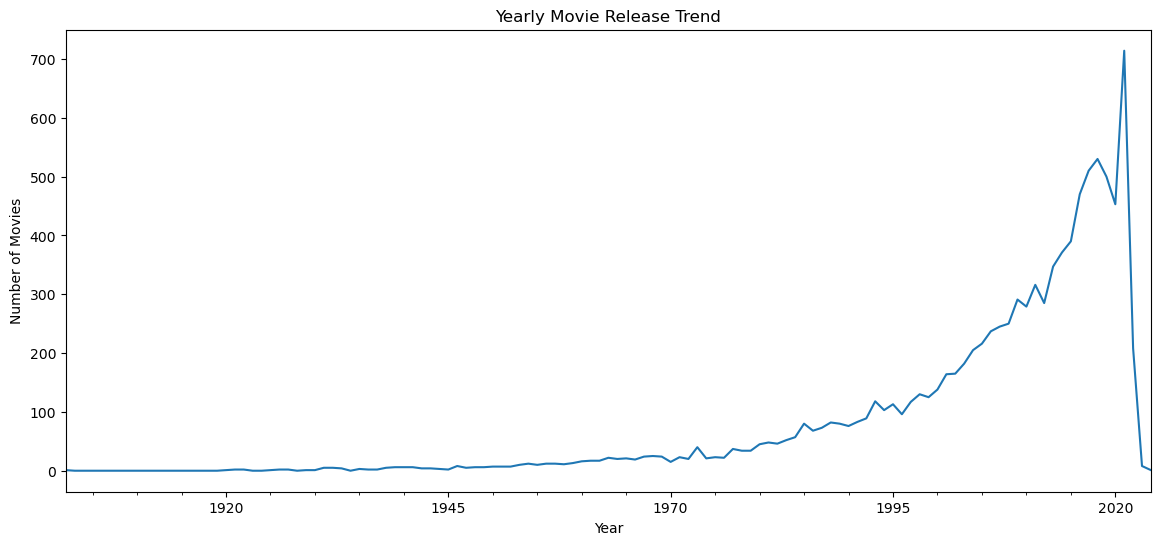

In [16]:
df = df.set_index("Release_Date", drop=False)

yearly = df.resample("YE").size()

yearly.plot(figsize=(14,6))
plt.title("Yearly Movie Release Trend")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()


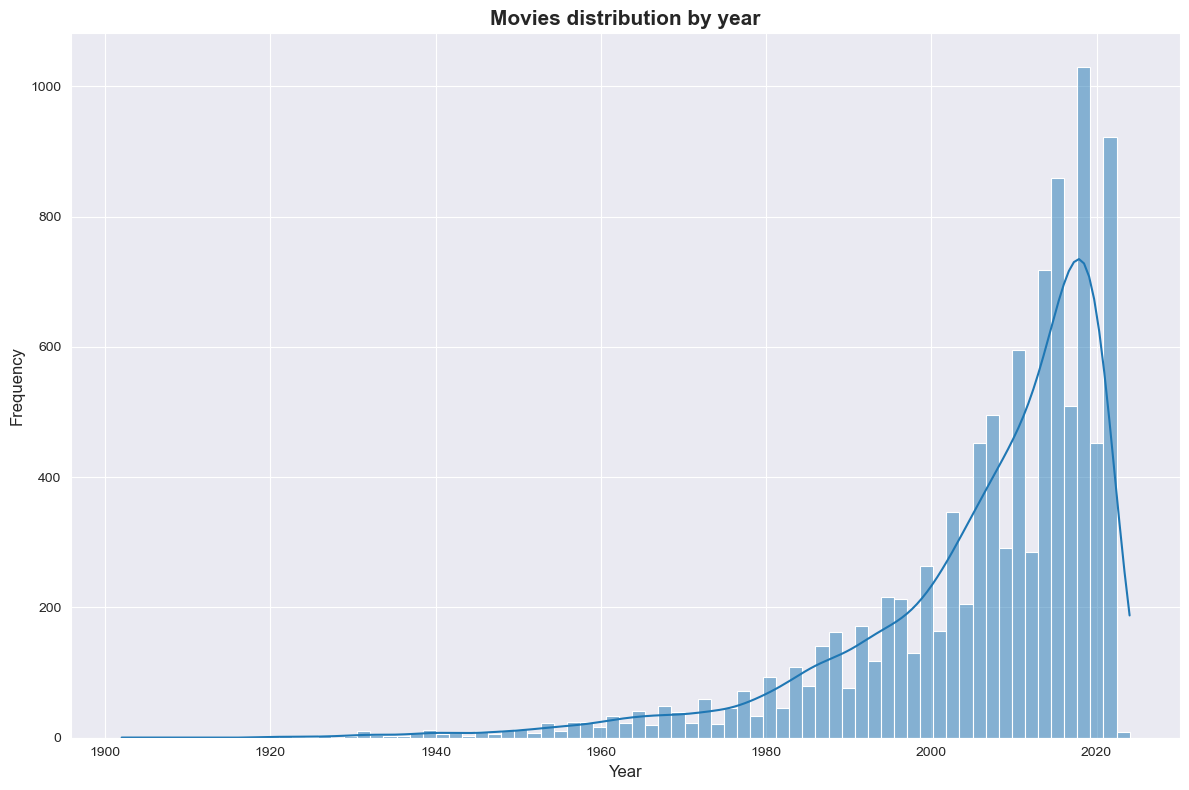

In [17]:
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Year", bins="fd", kde=True)
plt.title("Movies distribution by year", fontsize=15 , weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


The dataset spans movie releases from the early 1900s to 2020, with very few films in the early decades and a sharp increase in recent years. Most movies are concentrated between 2000 and 2020, making the distribution heavily skewed toward modern releases.

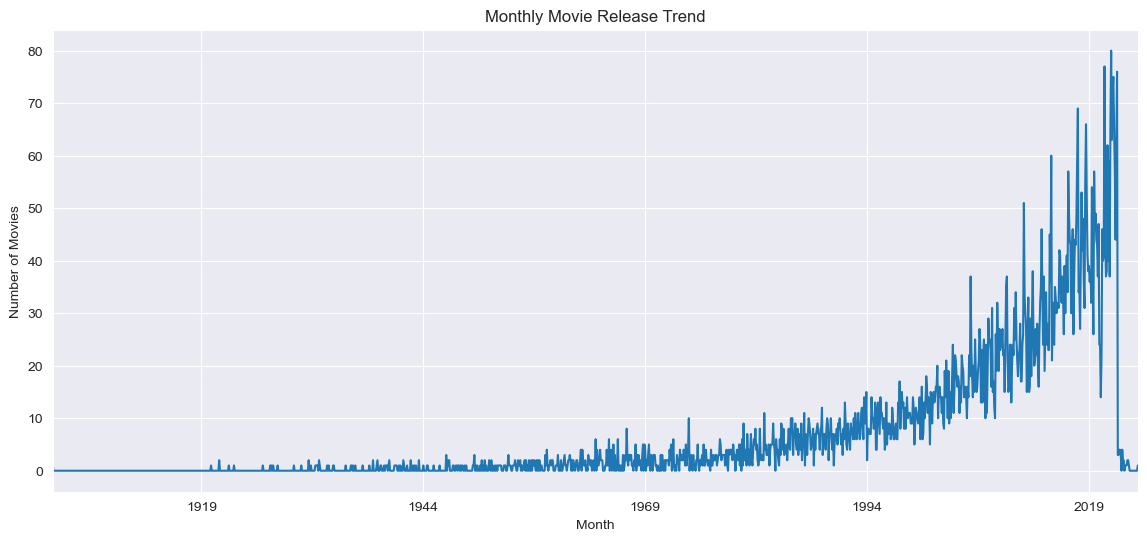

In [18]:
df = df.set_index("Release_Date", drop=False)

monthly = df.resample("ME").size()

monthly.plot(figsize=(14,6))
plt.title("Monthly Movie Release Trend")
plt.xlabel("Month")
plt.ylabel("Number of Movies")
plt.show()

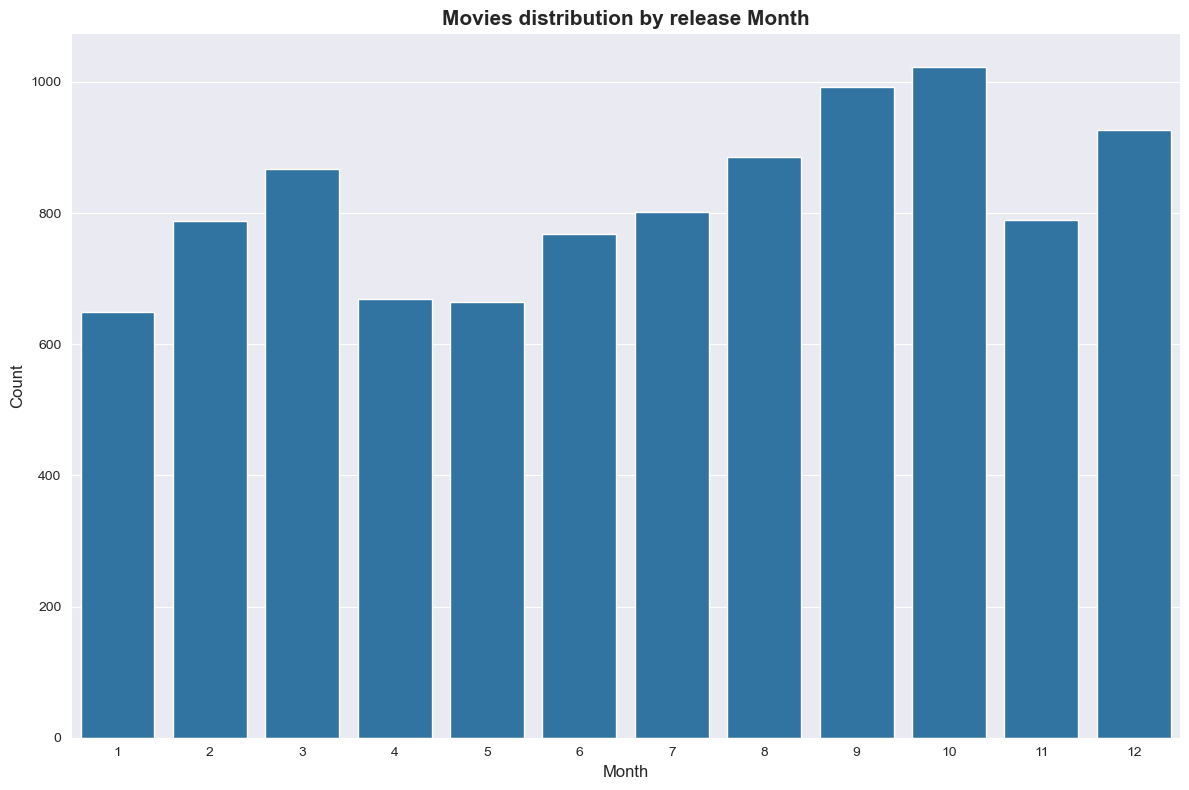

In [19]:
count = df.groupby("Month").size().reset_index(name="Count")
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.barplot(data = count , x="Month" , y="Count")
plt.title("Movies distribution by release Month", fontsize=15 , weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

October and September show the highest number of movie releases in the dataset. However, there is no clear or consistent month‑to‑month trend. In some parts of the year the number of releases increases from one month to the next, in others it remains relatively stable, and in some months it decreases. Overall, the distribution does not follow a smooth seasonal pattern, indicating that movie releases are spread irregularly across the calendar year.

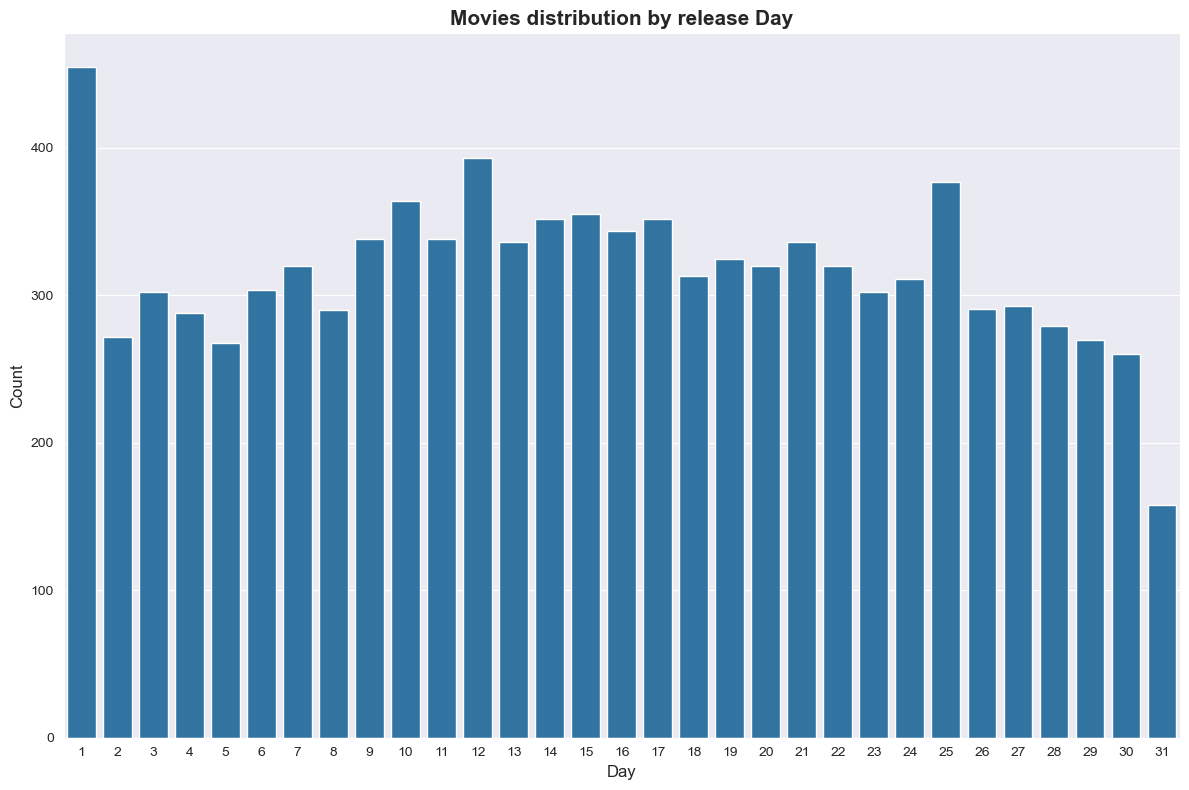

In [20]:
count = df.groupby("Day").size().reset_index(name="Count")
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.barplot(data = count , x="Day" , y="Count")
plt.title("Movies distribution by release Day", fontsize=15 , weight="bold")
plt.xlabel("Day", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

There is no clear pattern in the distribution of movie release days. Apart from the first day of the month, which shows a noticeably higher number of releases, the remaining days exhibit relatively similar frequencies. This suggests that, aside from a preference for releasing movies on the 1st, all other days of the month have roughly the same likelihood of being used as release dates, with no consistent upward or downward trend across the month.

## Popularity distribution

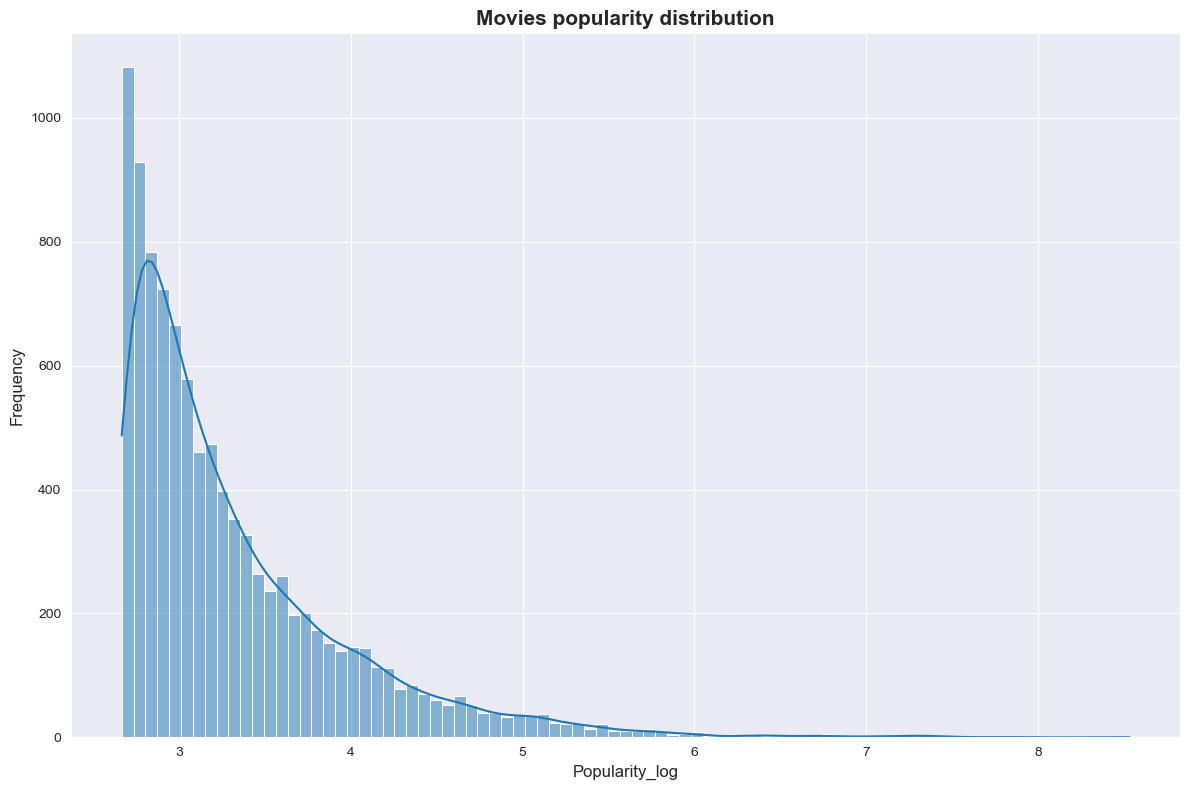

In [21]:
df["Popularity_log"]=np.log1p(df["Popularity"])
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Popularity_log", bins="fd", kde=True)
plt.title("Movies popularity distribution", fontsize=15 , weight="bold")
plt.xlabel("Popularity_log", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

Most movies have low popularity values, while only a small number achieve very high popularity. This creates a right‑skewed distribution, where the majority of observations cluster at the lower end and the tail extends toward higher popularity scores.

## Vote Count Distribution

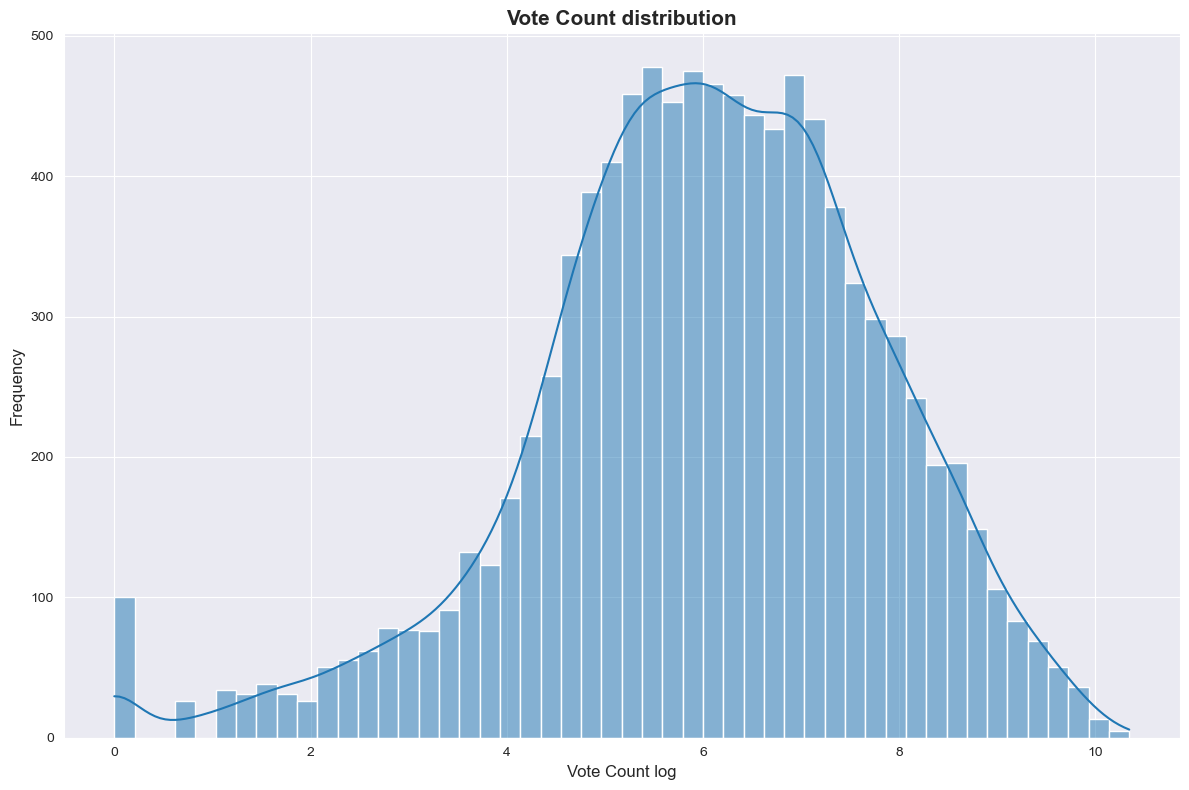

In [22]:
df["Vote_Count_log"]=np.log1p(df["Vote_Count"])
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Vote_Count_log", bins="fd", kde=True)
plt.title("Vote Count distribution", fontsize=15 , weight="bold")
plt.xlabel("Vote Count log", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
df["Vote_Count_log"].skew()

np.float64(-0.5873728991568369)

After applying a logarithmic transformation, the vote count distribution becomes more balanced but shows a slight left skew (skewness = –0.59). This indicates that a small number of movies have very low vote counts, while most movies cluster around moderate values.

## Vote Average Distribution

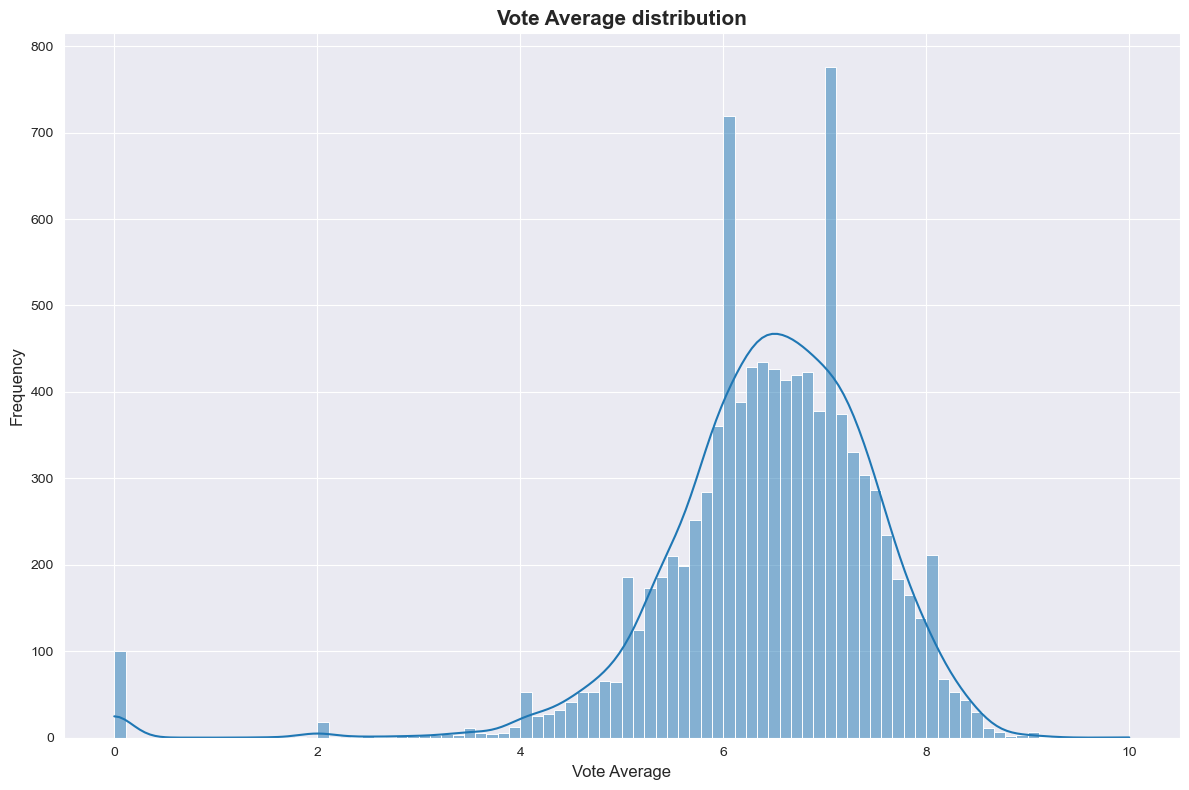

In [24]:
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Vote_Average", bins="fd", kde=True)
plt.title("Vote Average distribution", fontsize=15 , weight="bold")
plt.xlabel("Vote Average", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


The distribution is slightly left‑skewed, meaning the tail extends toward the lower vote‑average values. Most movies cluster around mid‑to‑high ratings, especially between 6 and 7, which appear to be the most common scores. Only a smaller number of movies receive very low ratings.

## Language Distribution

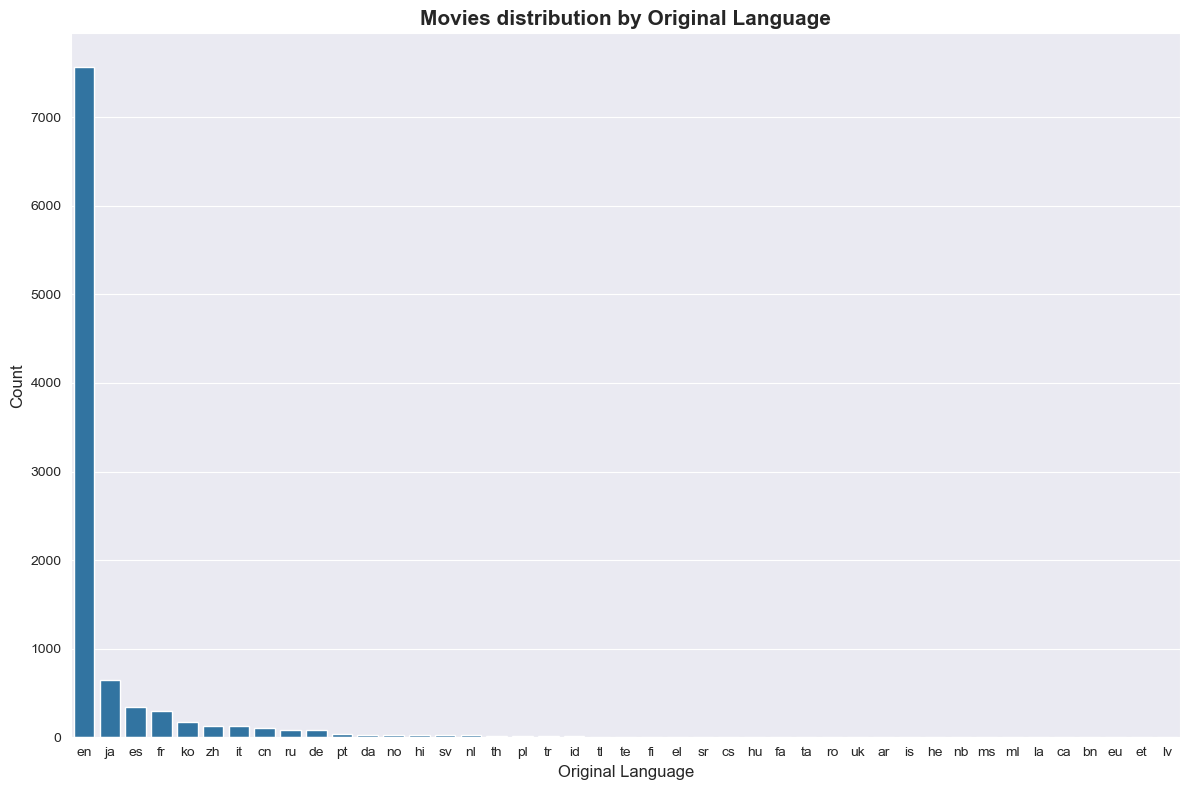

In [25]:
count = df.groupby("Original_Language").size().reset_index(name="Count")
count = count.sort_values("Count", ascending=False)
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.barplot(data = count , x="Original_Language" , y="Count")
plt.title("Movies distribution by Original Language", fontsize=15 , weight="bold")
plt.xlabel("Original Language", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
count = df.groupby("Original_Language").size().reset_index(name="Count")
count["Percentage"] = round((count["Count"] / count["Count"].sum()) * 100, 2)
count = count.sort_values("Count", ascending=False)

count.head()

,Original_Language,Count,Percentage
8,en,7569,77.03
21,ja,645,6.56
9,es,339,3.45
14,fr,292,2.97
22,ko,170,1.73


English dominates the dataset, accounting for about 77% of all movies. Japanese follows with around 6.5%, while Spanish, French, and Korean each contribute only a small share (between 1–3.5%). This shows that the dataset is heavily skewed toward English‑language productions, with all other languages representing relatively small proportions.

## Genre Dsitribution

In [27]:
Genre_list = df["Genre"].to_list()

all_genres = []

for g in Genre_list:
    parts = g.split(",")   # split by comma
    parts = [p.strip() for p in parts]  # remove spaces
    all_genres.extend(parts)

unique_genres = set(all_genres)

unique_genres

{'Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western'}

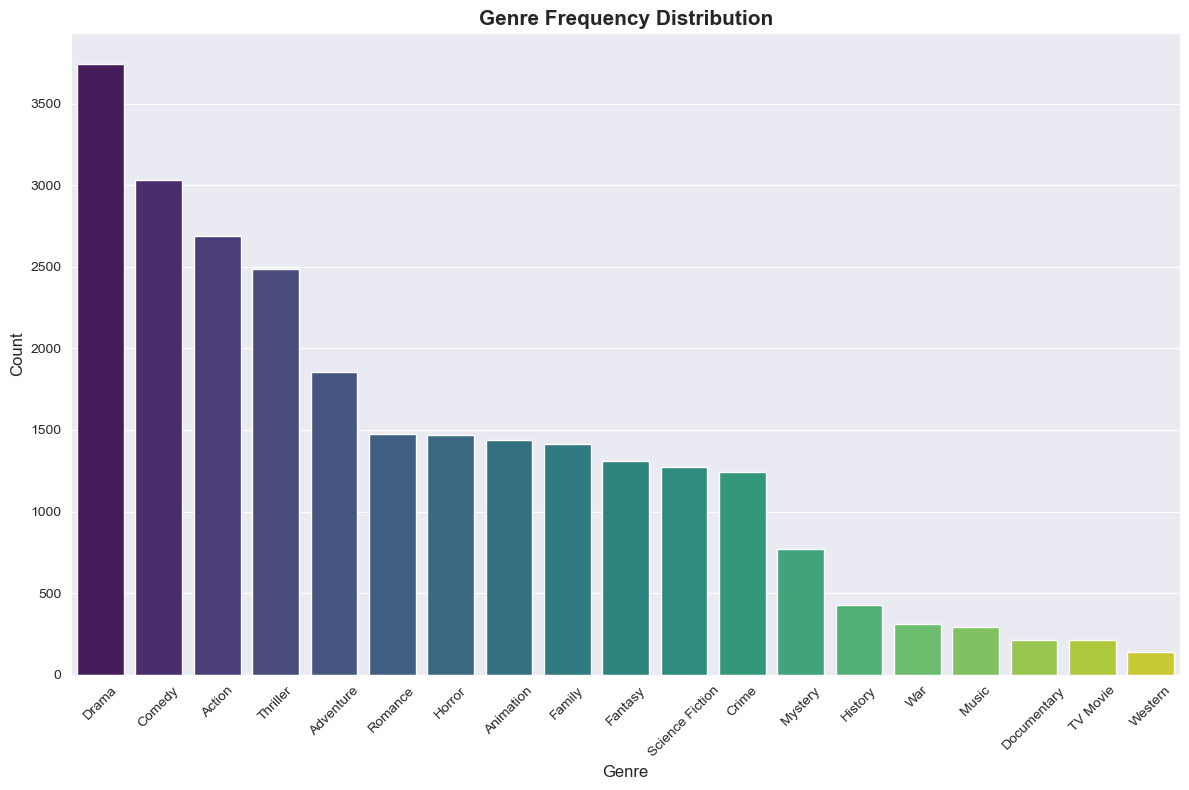

In [28]:
from collections import Counter

genre_counts = Counter(all_genres)

genre_df = pd.DataFrame(genre_counts.items(), columns=["Genre", "Count"])
genre_df = genre_df.sort_values("Count", ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=genre_df, x="Genre", y="Count", hue="Genre", palette="viridis", legend=False)
plt.title("Genre Frequency Distribution", fontsize=15, weight="bold")
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
genre_df["Percentage"] = round((genre_df["Count"] / genre_df["Count"].sum()) * 100, 2)
genre_df = genre_df.sort_values("Count", ascending=False).reset_index(drop=True)
genre_df

,Genre,Count,Percentage
0,Drama,3744,14.52
1,Comedy,3031,11.75
2,Action,2686,10.41
3,Thriller,2488,9.65
4,Adventure,1853,7.18
5,Romance,1476,5.72
6,Horror,1470,5.70
7,Animation,1438,5.58
8,Family,1414,5.48
9,Fantasy,1308,5.07


Drama is the most common genre, appearing in about 14.5% of all genre tags. Comedy follows with 11.75%, then Action with 10.41%, Thriller with 9.65%, and Adventure with 7.18%. This shows that the dataset is dominated by story‑driven genres (Drama, Comedy, Action), while more niche genres appear less frequently.

In [30]:
from itertools import combinations


df['genre_lists'] = df['Genre'].str.split(',')

pair_counter = Counter()

for genres in df['genre_lists']:
    # Only count pairs if there are 2+ genres
    if len(genres) > 1:
        pairs = combinations(sorted(genres), 2)
        pair_counter.update(pairs)

all_genres = sorted({g for sublist in df['genre_lists'] for g in sublist})

In [31]:
paired_genres = set([g for pair in pair_counter for g in pair])
paired_genres = sorted(paired_genres)


In [32]:
matrix = pd.DataFrame(0, index=paired_genres , columns=paired_genres )

In [33]:
for (g1, g2), count in pair_counter.items():
    matrix.loc[g1, g2] = count
    matrix.loc[g2, g1] = count   # symmetric


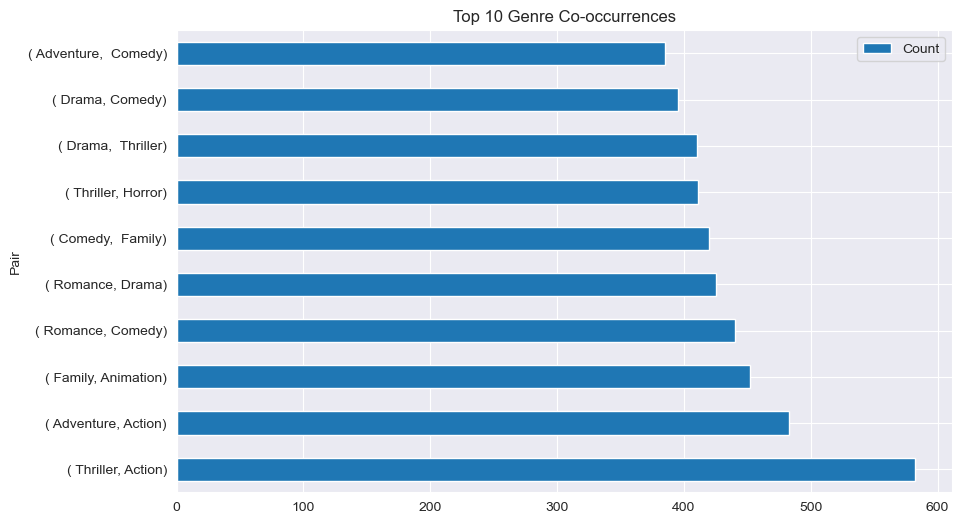

In [34]:
pair_df = pd.DataFrame(pair_counter.items(), columns=["Pair", "Count"])
pair_df = pair_df.sort_values("Count", ascending=False).head(10)

pair_df.plot(kind="barh", x="Pair", y="Count", figsize=(10,6))
plt.title("Top 10 Genre Co-occurrences")
plt.show()


## Clustering

In [61]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-mpnet-base-v2')
overview_embeddings = model.encode(df['Overview'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/308 [00:00<?, ?it/s]

In [62]:
X = overview_embeddings

In [66]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X)


In [67]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

le = LabelEncoder()
true_genre = le.fit_transform(df['Genre'])  # your real genre column

ari = adjusted_rand_score(true_genre, df['cluster'])
nmi = normalized_mutual_info_score(true_genre, df['cluster'])

print("ARI:", ari)
print("NMI:", nmi)


ARI: 0.022160869050380387
NMI: 0.23314883756664065


In [40]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url', 'Year',
       'Month', 'Day', 'Popularity_log', 'Vote_Count_log', 'genre_lists'],
      dtype='object')

In [43]:
df["genre_lists"]

Release_Date
2021-12-15     [Action,  Adventure,  Science Fiction]
2022-03-01               [Crime,  Mystery,  Thriller]
2022-02-25                                 [Thriller]
2021-11-24    [Animation,  Comedy,  Family,  Fantasy]
2021-12-22      [Action,  Adventure,  Thriller,  War]
                               ...                   
1973-10-15                            [Drama,  Crime]
2020-10-01                                   [Horror]
2016-05-06              [Mystery,  Thriller,  Horror]
2021-03-31                  [Music,  Drama,  History]
1984-09-23            [War,  Drama,  Science Fiction]
Name: genre_lists, Length: 9826, dtype: object